## 1. Environment Setup & Imports

In [1]:
!pip install pdfplumber nltk spacy wordcloud matplotlib seaborn scikit-learn pandas numpy tqdm
!python -m spacy download en_core_web_sm
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
D:\IIT\Degree - AI and Data Science\2nd Year - 1st Sem\DSGP\call-center-automation\rag-multi-agent\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB 1.3 MB/s eta 0:00:10
     ---------------------------------------- 0.0/12.8 MB 1.3 MB/s eta 0:00:10
     --------------------------------------- 0.1/12.8 MB 657.6 kB/s eta 0:00:20
     --------------------------------------- 0.1/12.8 MB 595.3 kB/s eta 0:00:22
     --------------------------------------- 0.1/12.8 MB 607.9 kB/s eta 0:00:21
      -------------------------------------- 0.2/12.8 MB 692.4 kB/s eta 0:00:19
      -------------------------------------- 0.3/12.8 MB 785.2 kB/s eta 0:00:16
     - -------------------------------------- 0.4/12.8 MB 1.0 MB/s eta 0:00:12
     - -------------------------------------- 0.4/12.8 MB 1.0 MB/s eta 0:00:12
     - -------------------------------------- 0.4/12.8 MB 1.0 MB/s e

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
import json
import hashlib
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import pdfplumber

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.size': 11,
})
PALETTE = ['#4361ee', '#f72585', '#4cc9f0', '#7209b7', '#3a0ca3', '#560bad']

In [3]:
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pdf_files = sorted(DATA_DIR.glob("**/*.pdf"))

print(f"Data directory : {DATA_DIR.resolve()}")
print(f"PDFs found     : {len(pdf_files)}")

if not pdf_files:
    print("No PDFs found")

Data directory : D:\IIT\Degree - AI and Data Science\2nd Year - 1st Sem\DSGP\call-center-automation\rag-multi-agent\data
PDFs found     : 5


## 3. PDF Text Extraction

In [4]:
def extract_text_from_pdf(pdf_path: Path) -> dict:
    pages = []
    full_text_parts = []

    try:
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                page_text = page.extract_text() or ""
                page_text = page_text.strip()
                pages.append({
                    "page_number": i + 1,
                    "raw_text": page_text,
                    "char_count": len(page_text),
                    "word_count": len(page_text.split()),
                    "is_empty": len(page_text.strip()) == 0,
                })
                if page_text.strip():
                    full_text_parts.append(page_text)

        full_text = "\n\n".join(full_text_parts)
        doc_hash = hashlib.sha256(full_text.encode("utf-8")).hexdigest()[:12]

        return {
            "filename": pdf_path.name,
            "filepath": str(pdf_path),
            "doc_id": doc_hash,
            "total_pages": len(pages),
            "empty_pages": sum(1 for p in pages if p["is_empty"]),
            "full_text": full_text,
            "total_chars": len(full_text),
            "total_words": len(full_text.split()),
            "pages": pages,
            "extraction_status": "ok" if full_text.strip() else "empty",
        }

    except Exception as e:
        print(f"Failed to extract {pdf_path.name}: {e}")
        return {
            "filename": pdf_path.name,
            "filepath": str(pdf_path),
            "doc_id": "",
            "total_pages": 0, "empty_pages": 0,
            "full_text": "", "total_chars": 0, "total_words": 0,
            "pages": [],
            "extraction_status": f"error: {e}",
        }


documents = []
for pdf_path in tqdm(pdf_files, desc="Extracting"):
    doc = extract_text_from_pdf(pdf_path)
    documents.append(doc)
    print(f"{doc['filename']:<50} "
          f"{doc['total_pages']} pages | "
          f"{doc['total_words']:,} words | "
          f"{doc['empty_pages']} empty pages")

print(f"\nTotal documents extracted: {len(documents)}")
print(f"Total words in corpus    : {sum(d['total_words'] for d in documents):,}")
print(f"Total characters         : {sum(d['total_chars'] for d in documents):,}")

Extracting:  20%|██        | 1/5 [00:00<00:01,  2.77it/s]

LankaLink_Customer_Support_Manual.pdf              3 pages | 440 words | 0 empty pages


Extracting:  40%|████      | 2/5 [00:01<00:01,  1.80it/s]

LankaLink_SIM_Card_Support_Manual.pdf              9 pages | 966 words | 0 empty pages


Extracting:  60%|██████    | 3/5 [00:01<00:01,  1.78it/s]

LankaLink_SIM_Card_Support_Manual_v2.pdf           9 pages | 1,017 words | 0 empty pages
SIM_Card_Service_Support_Manual.pdf                1 pages | 202 words | 0 empty pages


Extracting: 100%|██████████| 5/5 [00:01<00:00,  2.50it/s]

WiFi_and_Broadband_Support_Manual.pdf              1 pages | 195 words | 0 empty pages

Total documents extracted: 5
Total words in corpus    : 2,820
Total characters         : 18,629


## 4. Document-Level EDA

### 4.1 Corpus Overview Table

In [5]:
doc_summary = pd.DataFrame([{
    "Document": d["filename"],
    "Pages": d["total_pages"],
    "Empty Pages": d["empty_pages"],
    "Total Words": d["total_words"],
    "Total Chars": d["total_chars"],
    "Avg Words/Page": round(d["total_words"] / max(d["total_pages"], 1), 1),
    "Status": d["extraction_status"],
} for d in documents])

doc_summary = doc_summary.sort_values("Total Words", ascending=False).reset_index(drop=True)

print(doc_summary.to_string(index=False))
print()
print(f"  Total documents : {len(doc_summary)}")
print(f"  Total pages     : {doc_summary['Pages'].sum()}")
print(f"  Total words     : {doc_summary['Total Words'].sum():,}")
print(f"  Avg words/doc   : {doc_summary['Total Words'].mean():.0f}")

                                Document  Pages  Empty Pages  Total Words  Total Chars  Avg Words/Page Status
LankaLink_SIM_Card_Support_Manual_v2.pdf      9            0         1017         6565           113.0     ok
   LankaLink_SIM_Card_Support_Manual.pdf      9            0          966         6257           107.3     ok
   LankaLink_Customer_Support_Manual.pdf      3            0          440         2959           146.7     ok
     SIM_Card_Service_Support_Manual.pdf      1            0          202         1486           202.0     ok
   WiFi_and_Broadband_Support_Manual.pdf      1            0          195         1362           195.0     ok

  Total documents : 5
  Total pages     : 23
  Total words     : 2,820
  Avg words/doc   : 564


### 4.2 Word Count Distribution Across Documents

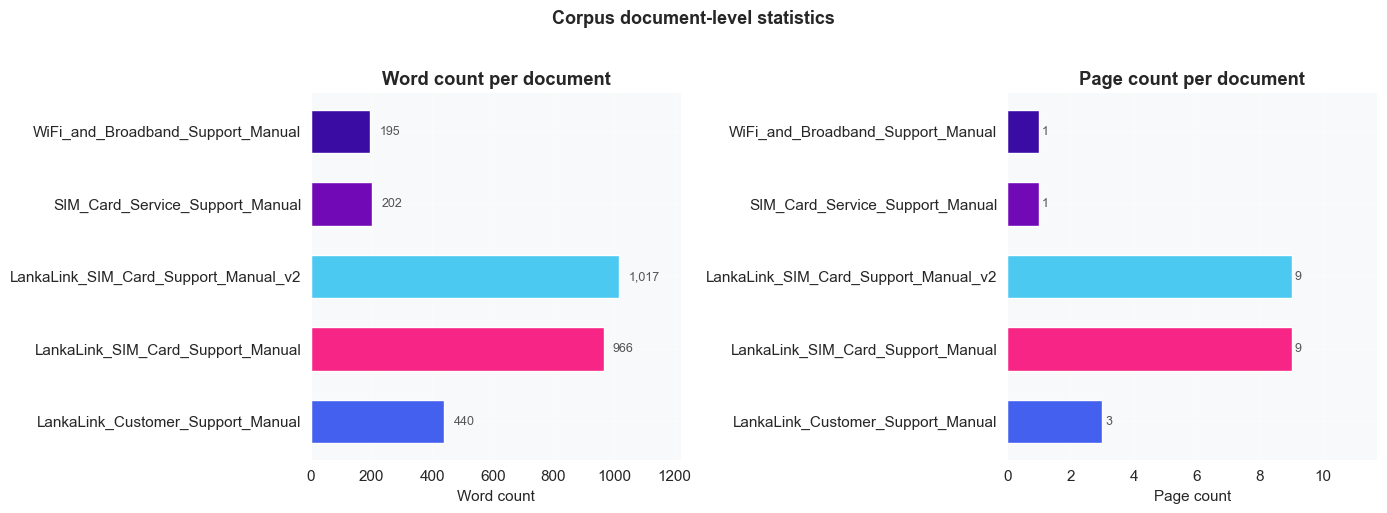

Figure saved: outputs/01_document_stats.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
names = [d["filename"].replace(".pdf", "") for d in documents]
words = [d["total_words"] for d in documents]
colors = PALETTE[:len(names)]
bars = ax.barh(names, words, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, words):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va='center', fontsize=9, color='#555')

ax.set_xlabel("Word count")
ax.set_title("Word count per document", fontweight='bold')
ax.set_xlim(0, max(words) * 1.2)

ax = axes[1]
pages = [d["total_pages"] for d in documents]
bars = ax.barh(names, pages, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, pages):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9, color='#555')

ax.set_xlabel("Page count")
ax.set_title("Page count per document", fontweight='bold')
ax.set_xlim(0, max(pages) * 1.3)

plt.suptitle("Corpus document-level statistics", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_document_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/01_document_stats.png")

### 4.3 Page-Level Word Count Distribution

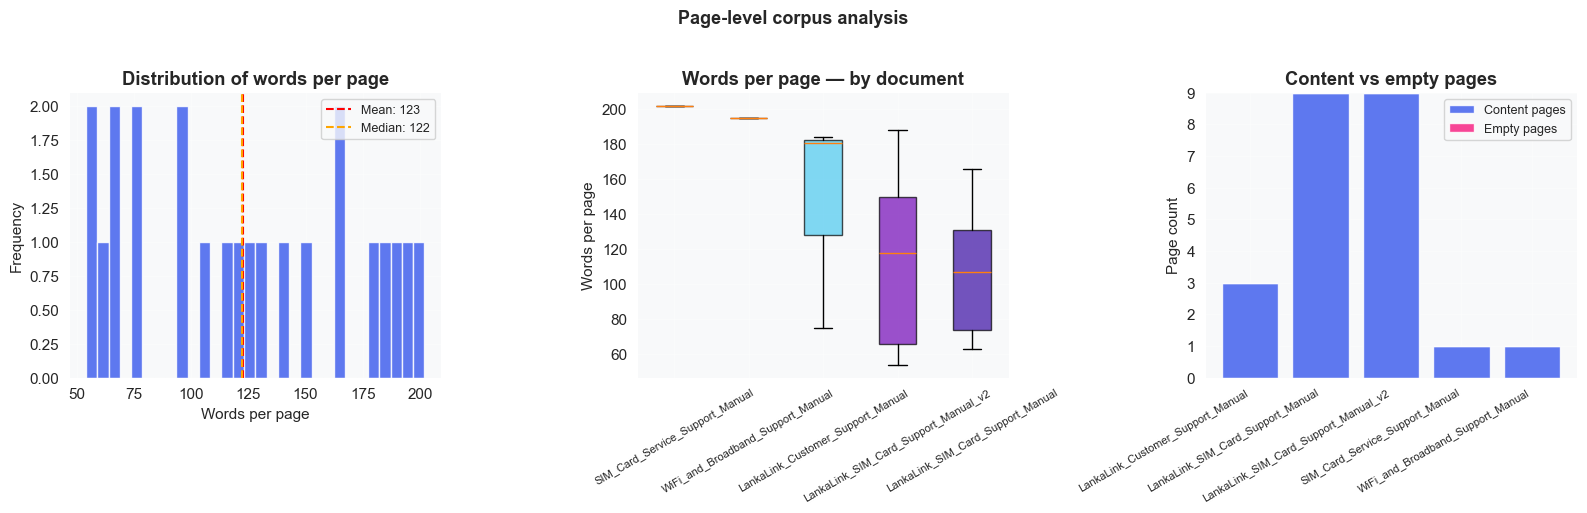

Figure saved: outputs/02_page_level_stats.png


In [7]:
page_records = []
for doc in documents:
    for page in doc["pages"]:
        page_records.append({
            "document": doc["filename"].replace(".pdf", ""),
            "page_number": page["page_number"],
            "word_count": page["word_count"],
            "char_count": page["char_count"],
            "is_empty": page["is_empty"],
        })

pages_df = pd.DataFrame(page_records)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.hist(pages_df["word_count"], bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.axvline(pages_df["word_count"].mean(), color='red', linestyle='--',
           label=f'Mean: {pages_df["word_count"].mean():.0f}')
ax.axvline(pages_df["word_count"].median(), color='orange', linestyle='--',
           label=f'Median: {pages_df["word_count"].median():.0f}')
ax.set_xlabel("Words per page")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of words per page", fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
docs_order = pages_df.groupby('document')['word_count'].median().sort_values(ascending=False).index.tolist()
data_by_doc = [pages_df[pages_df['document'] == d]['word_count'].values for d in docs_order]
bp = ax.boxplot(data_by_doc, labels=docs_order, patch_artist=True, vert=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Words per page")
ax.set_title("Words per page — by document", fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=8)

ax = axes[2]
empty_counts = [d["empty_pages"] for d in documents]
content_counts = [d["total_pages"] - d["empty_pages"] for d in documents]
doc_names = [d["filename"].replace(".pdf", "") for d in documents]
x = range(len(doc_names))
ax.bar(x, content_counts, label="Content pages", color=PALETTE[0], alpha=0.85)
ax.bar(x, empty_counts, bottom=content_counts, label="Empty pages", color='#f72585', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(doc_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel("Page count")
ax.set_title("Content vs empty pages", fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle("Page-level corpus analysis", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_page_level_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/02_page_level_stats.png")

### 4.4 Descriptive Statistics Summary

In [8]:
non_empty_pages = pages_df[~pages_df["is_empty"]]

print(" PAGE-LEVEL STATISTICS (non-empty pages only)")
stats = non_empty_pages["word_count"].describe(percentiles=[0.25, 0.50, 0.75, 0.90])
print(stats.to_string())

print(" DATA QUALITY REPORT")
total_pages = len(pages_df)
empty_pages = pages_df["is_empty"].sum()
short_pages = (pages_df["word_count"] < 50).sum()
quality_score = ((total_pages - empty_pages) / total_pages) * 100

print(f"Total pages        : {total_pages}")
print(f"Empty pages        : {empty_pages}  ({empty_pages / total_pages * 100:.1f}%)")
print(f"Short pages (<50w) : {short_pages}  ({short_pages / total_pages * 100:.1f}%)")
print(f"Data quality score : {quality_score:.1f}%")
print()
if quality_score < 85:
    print("Quality below 85% OCR fallback may be needed for some documents")
else:
    print("Corpus quality is good pdfplumber extraction succeeded")

 PAGE-LEVEL STATISTICS (non-empty pages only)
count     23.000000
mean     122.608696
std       49.227431
min       54.000000
25%       74.500000
50%      122.000000
75%      166.500000
90%      187.200000
max      202.000000
 DATA QUALITY REPORT
Total pages        : 23
Empty pages        : 0  (0.0%)
Short pages (<50w) : 0  (0.0%)
Data quality score : 100.0%

Corpus quality is good pdfplumber extraction succeeded


## 5. Token & Vocabulary Analysis

### 5.1 Tokenisation and Sentence Statistics

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def tokenize_clean(text: str) -> list:
    tokens = word_tokenize(text.lower())
    return [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in stop_words and len(t) > 2
    ]


doc_token_stats = []
all_tokens_combined = []

for doc in tqdm(documents, desc="Tokenising"):
    tokens = tokenize_clean(doc["full_text"])
    sentences = sent_tokenize(doc["full_text"])
    vocab = set(tokens)

    doc["tokens"] = tokens
    doc["sentences"] = sentences
    doc["vocab_size"] = len(vocab)
    doc["sentence_count"] = len(sentences)
    doc["avg_sent_len"] = np.mean([len(s.split()) for s in sentences]) if sentences else 0

    all_tokens_combined.extend(tokens)
    doc_token_stats.append({
        "Document": doc["filename"].replace(".pdf", ""),
        "Tokens (clean)": len(tokens),
        "Vocabulary": len(vocab),
        "Sentences": len(sentences),
        "Avg sent length": round(doc["avg_sent_len"], 1),
        "Lexical density": round(len(vocab) / max(len(tokens), 1), 3),
    })

token_stats_df = pd.DataFrame(doc_token_stats)
print(" TOKEN & VOCABULARY STATISTICS")
print(token_stats_df.to_string(index=False))
print()
print(f"  Corpus-wide vocabulary : {len(set(all_tokens_combined)):,} unique tokens")
print(f"  Total clean tokens     : {len(all_tokens_combined):,}")

Tokenising: 100%|██████████| 5/5 [00:07<00:00,  1.43s/it]

 TOKEN & VOCABULARY STATISTICS
                            Document  Tokens (clean)  Vocabulary  Sentences  Avg sent length  Lexical density
   LankaLink_Customer_Support_Manual             294         164         42             10.5            0.558
   LankaLink_SIM_Card_Support_Manual             647         307        100              9.7            0.474
LankaLink_SIM_Card_Support_Manual_v2             697         298        105              9.7            0.428
     SIM_Card_Service_Support_Manual             150         100         13             15.5            0.667
   WiFi_and_Broadband_Support_Manual             134          98         12             16.2            0.731

  Corpus-wide vocabulary : 536 unique tokens
  Total clean tokens     : 1,922


### 5.2 Vocabulary Statistics Visualisation

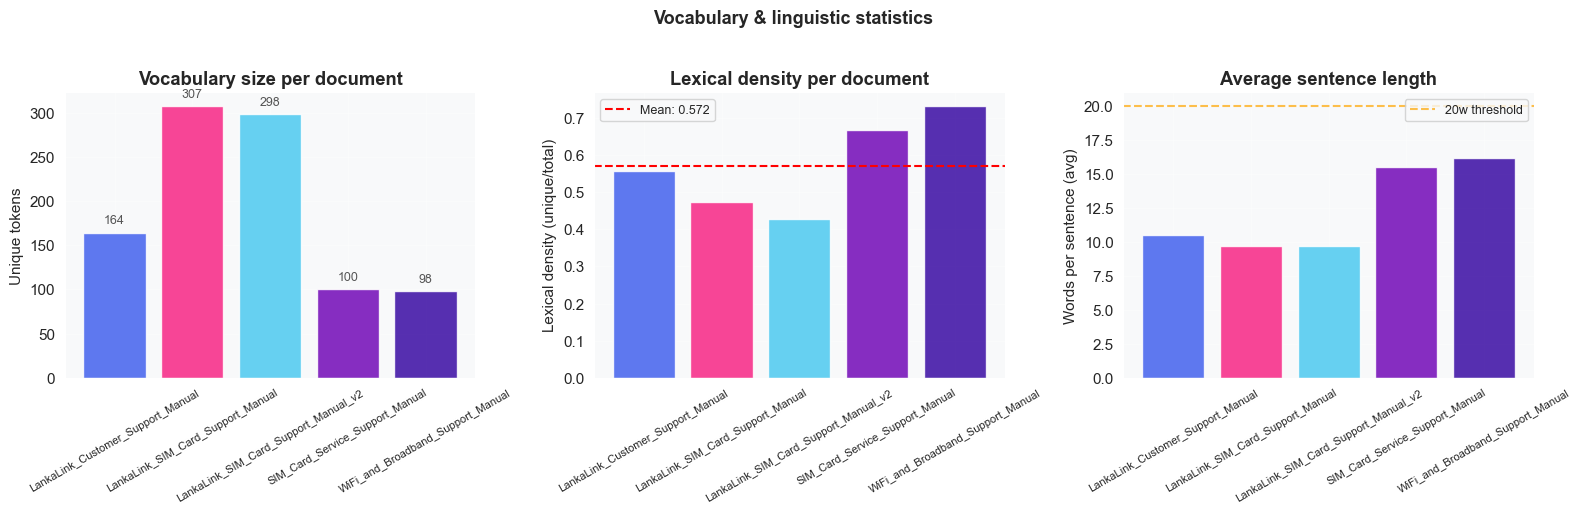

Figure saved: outputs/03_vocabulary_stats.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.bar(token_stats_df["Document"], token_stats_df["Vocabulary"],
       color=PALETTE[:len(token_stats_df)], edgecolor='white', alpha=0.85)
ax.set_ylabel("Unique tokens")
ax.set_title("Vocabulary size per document", fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(token_stats_df["Vocabulary"]):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9, color='#555')

ax = axes[1]
ax.bar(token_stats_df["Document"], token_stats_df["Lexical density"],
       color=PALETTE[:len(token_stats_df)], edgecolor='white', alpha=0.85)
ax.axhline(token_stats_df["Lexical density"].mean(), color='red',
           linestyle='--', label=f'Mean: {token_stats_df["Lexical density"].mean():.3f}')
ax.set_ylabel("Lexical density (unique/total)")
ax.set_title("Lexical density per document", fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.legend(fontsize=9)

ax = axes[2]
ax.bar(token_stats_df["Document"], token_stats_df["Avg sent length"],
       color=PALETTE[:len(token_stats_df)], edgecolor='white', alpha=0.85)
ax.axhline(20, color='orange', linestyle='--', label='20w threshold', alpha=0.7)
ax.set_ylabel("Words per sentence (avg)")
ax.set_title("Average sentence length", fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.legend(fontsize=9)

plt.suptitle("Vocabulary & linguistic statistics", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_vocabulary_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/03_vocabulary_stats.png")

## 6. TF-IDF Term Frequency Analysis

In [11]:
corpus_texts = [doc["full_text"] for doc in documents]
doc_names_clean = [d["filename"].replace(".pdf", "") for d in documents]

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_texts)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"    {tfidf_matrix.shape[0]} documents - {tfidf_matrix.shape[1]} features")

print("\n" + "=" * 70)
print(" TOP 15 TF-IDF TERMS PER DOCUMENT")
print("=" * 70)
for i, doc_name in enumerate(doc_names_clean):
    row = tfidf_matrix[i].toarray()[0]
    top15 = sorted(enumerate(row), key=lambda x: x[1], reverse=True)[:15]
    terms = [(feature_names[idx], round(score, 4)) for idx, score in top15 if score > 0]
    print(f"\n  {doc_name}")
    for term, score in terms:
        print(f"     {term:<35} {score}")

TF-IDF matrix shape : (5, 500)
    5 documents - 500 features

 TOP 15 TF-IDF TERMS PER DOCUMENT

  LankaLink_Customer_Support_Manual
     ask                                 0.1984
     router                              0.1889
     ask customer                        0.1814
     fi                                  0.1595
     restart router                      0.1595
     sim                                 0.1493
     broadband                           0.1464
     step                                0.1464
     account                             0.1287
     centre                              0.1287
     centre agents                       0.1287
     checking                            0.1287
     issue cause                         0.1287
     ssid                                0.1287
     wifi                                0.1262

  LankaLink_SIM_Card_Support_Manual
     roaming                             0.1225
     sim                                 0.1208
     apn     

### 6.1 TF-IDF Top Terms Visualisation

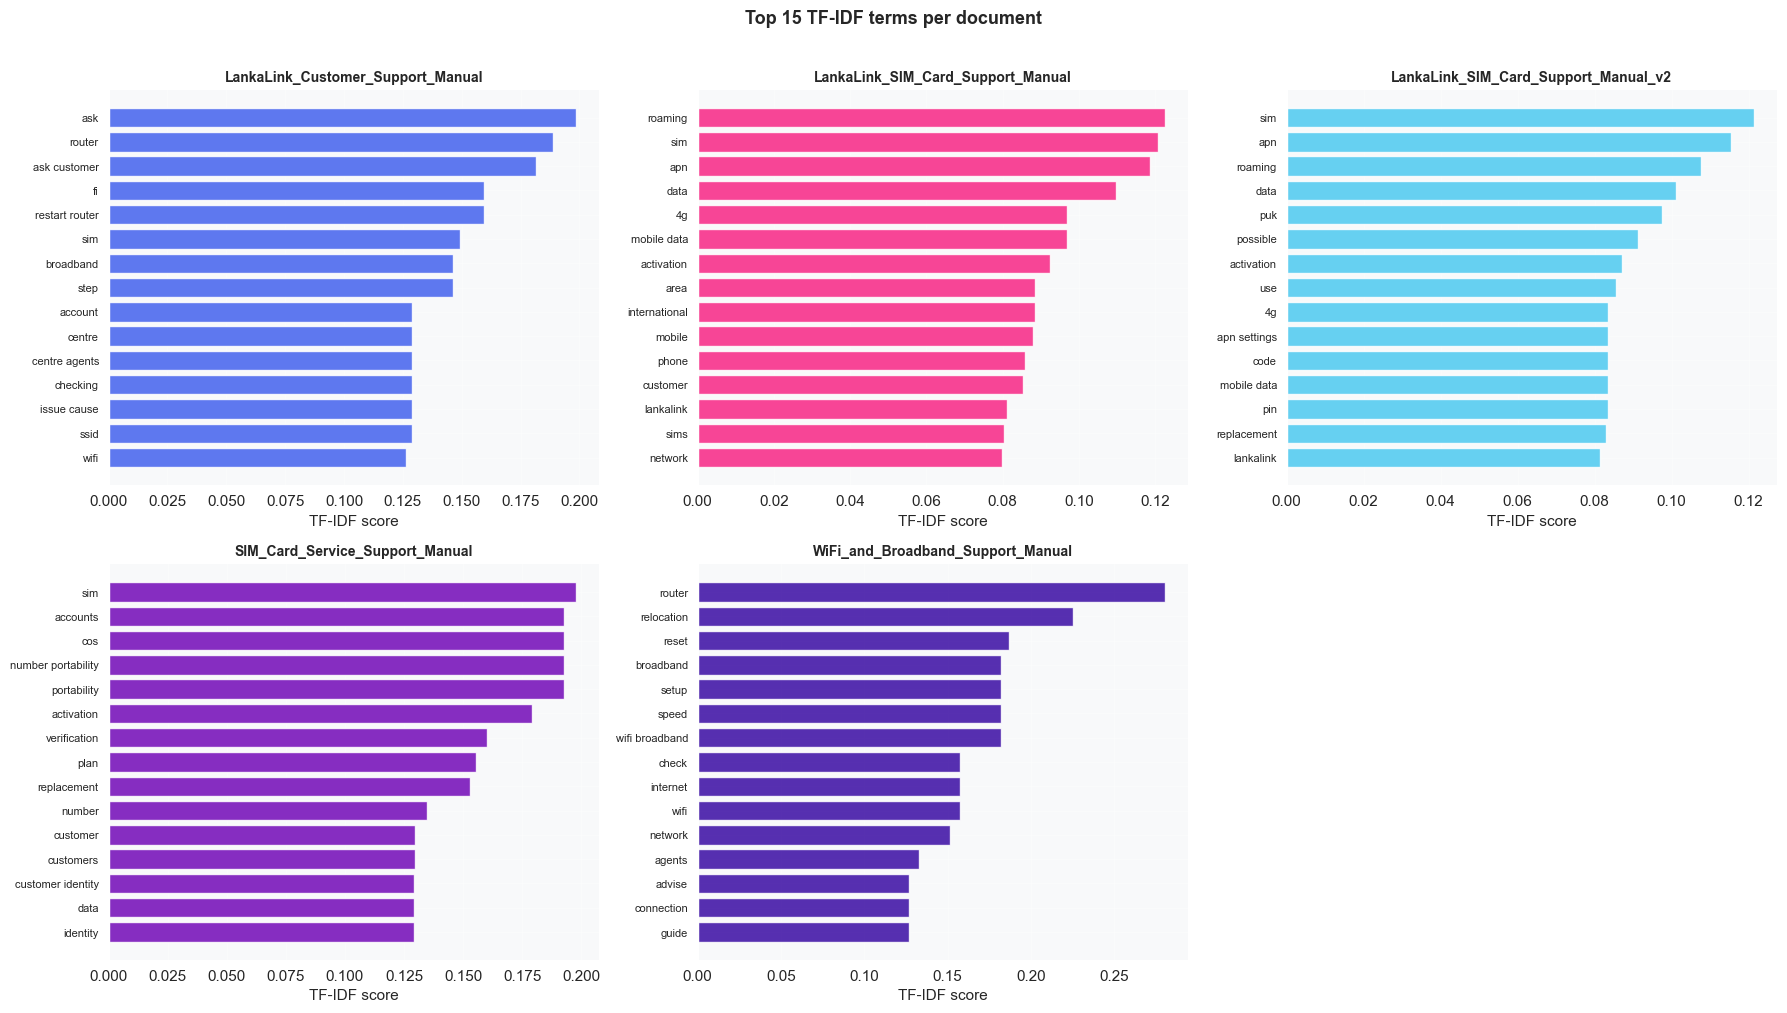

Figure saved: outputs/04_tfidf_top_terms.png


In [12]:
n_docs = len(documents)
TOP_N = 15

ncols = min(n_docs, 3)
nrows = (n_docs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes_flat = [axes] if n_docs == 1 else (axes.flatten() if nrows > 1 else axes)
if n_docs == 1:
    axes_flat = [axes]
elif nrows == 1:
    axes_flat = list(axes) if hasattr(axes, '__iter__') else [axes]
else:
    axes_flat = axes.flatten().tolist()

for i, (doc, ax) in enumerate(zip(documents, axes_flat)):
    row = tfidf_matrix[i].toarray()[0]
    top_n = sorted(enumerate(row), key=lambda x: x[1], reverse=True)[:TOP_N]
    terms = [feature_names[idx] for idx, _ in top_n]
    scores = [score for _, score in top_n]

    ax.barh(terms[::-1], scores[::-1],
            color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.85)
    ax.set_title(doc["filename"].replace(".pdf", ""), fontweight='bold', fontsize=10)
    ax.set_xlabel("TF-IDF score")
    ax.tick_params(axis='y', labelsize=8)

for ax in axes_flat[n_docs:]:
    ax.set_visible(False)

plt.suptitle(f"Top {TOP_N} TF-IDF terms per document", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_tfidf_top_terms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/04_tfidf_top_terms.png")

### 6.2 TF-IDF Heatmap — Topic Coverage Across Corpus

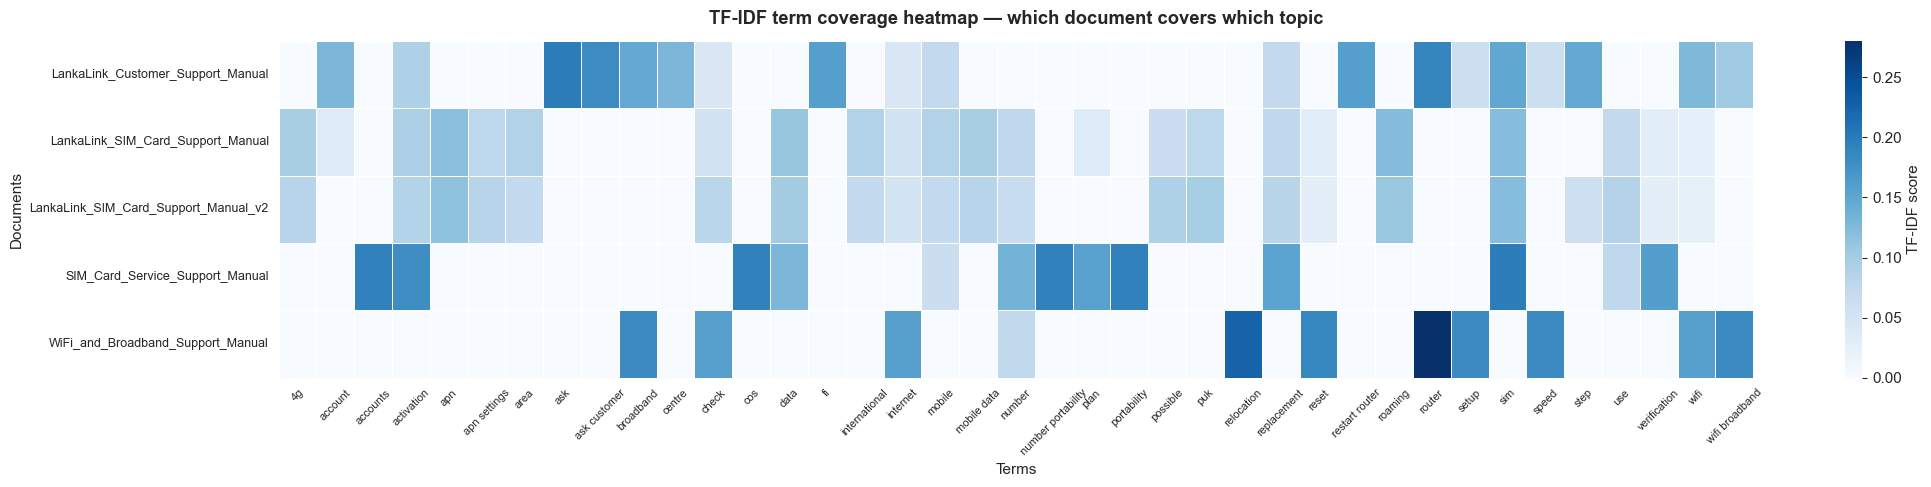

Figure saved: outputs/05_tfidf_heatmap.png


In [13]:
heatmap_terms = set()
for i in range(len(documents)):
    row = tfidf_matrix[i].toarray()[0]
    top10 = sorted(enumerate(row), key=lambda x: x[1], reverse=True)[:10]
    for idx, score in top10:
        if score > 0:
            heatmap_terms.add(feature_names[idx])

heatmap_terms = sorted(heatmap_terms)
heatmap_indices = [list(feature_names).index(t) for t in heatmap_terms]

hm_data = tfidf_matrix[:, heatmap_indices].toarray()
hm_df = pd.DataFrame(hm_data, index=doc_names_clean, columns=heatmap_terms)

fig, ax = plt.subplots(figsize=(max(14, len(heatmap_terms) * 0.55), max(5, len(documents) * 0.9)))
sns.heatmap(
    hm_df,
    ax=ax,
    cmap="Blues",
    annot=False,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'TF-IDF score'},
)
ax.set_title("TF-IDF term coverage heatmap — which document covers which topic",
             fontweight='bold', pad=12)
ax.set_xlabel("Terms")
ax.set_ylabel("Documents")
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_tfidf_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/05_tfidf_heatmap.png")

## 7. Word Frequency Analysis

### 7.1 Top Unigrams Across Corpus

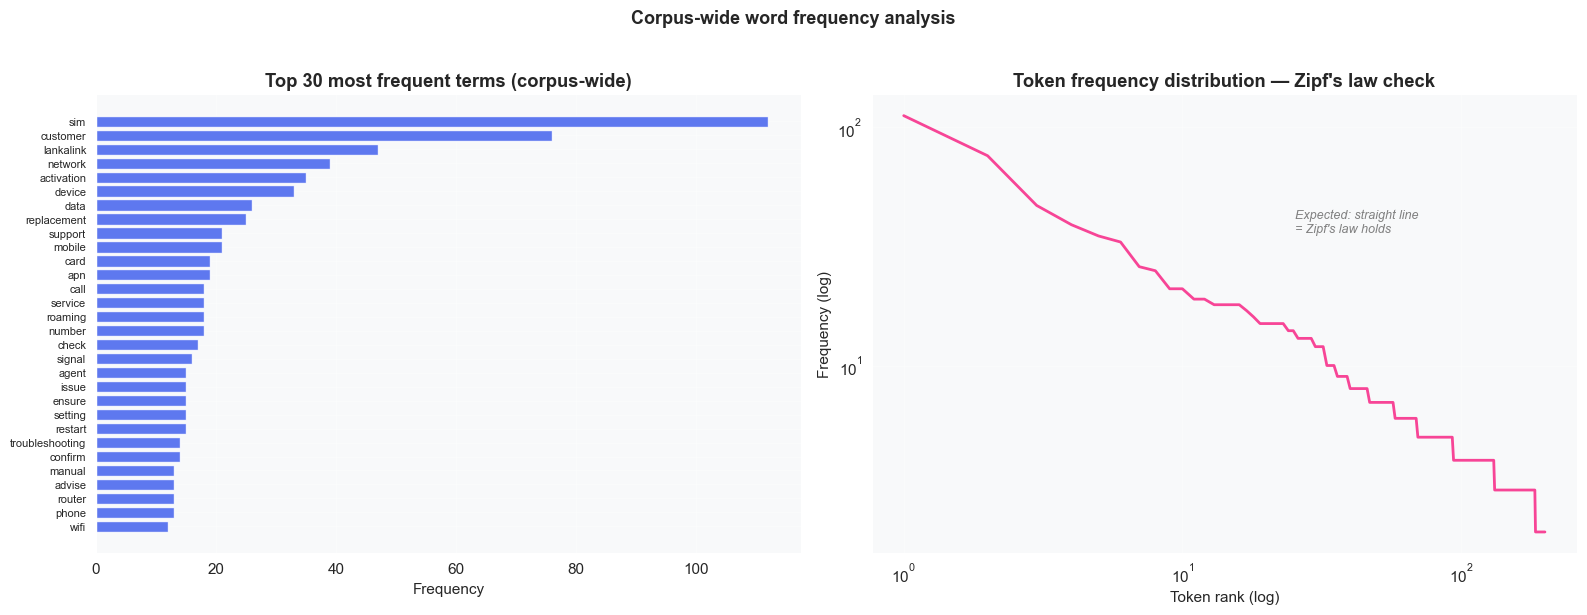

Figure saved: outputs/06_word_frequency.png


In [14]:
token_freq = Counter(all_tokens_combined)
top_50 = token_freq.most_common(50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
top30_terms = [t for t, _ in top_50[:30]]
top30_counts = [c for _, c in top_50[:30]]
ax.barh(top30_terms[::-1], top30_counts[::-1],
        color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.set_xlabel("Frequency")
ax.set_title("Top 30 most frequent terms (corpus-wide)", fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

ax = axes[1]
all_counts = sorted([c for _, c in token_freq.items()], reverse=True)
ranks = list(range(1, len(all_counts) + 1))
ax.loglog(ranks[:200], all_counts[:200],
          color=PALETTE[1], linewidth=2, alpha=0.85)
ax.set_xlabel("Token rank (log)")
ax.set_ylabel("Frequency (log)")
ax.set_title("Token frequency distribution — Zipf's law check", fontweight='bold')
ax.annotate("Expected: straight line\n= Zipf's law holds",
            xy=(0.6, 0.7), xycoords='axes fraction', fontsize=9,
            color='gray', style='italic')

plt.suptitle("Corpus-wide word frequency analysis", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_word_frequency.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/06_word_frequency.png")

### 7.2 Wordclouds Per Document

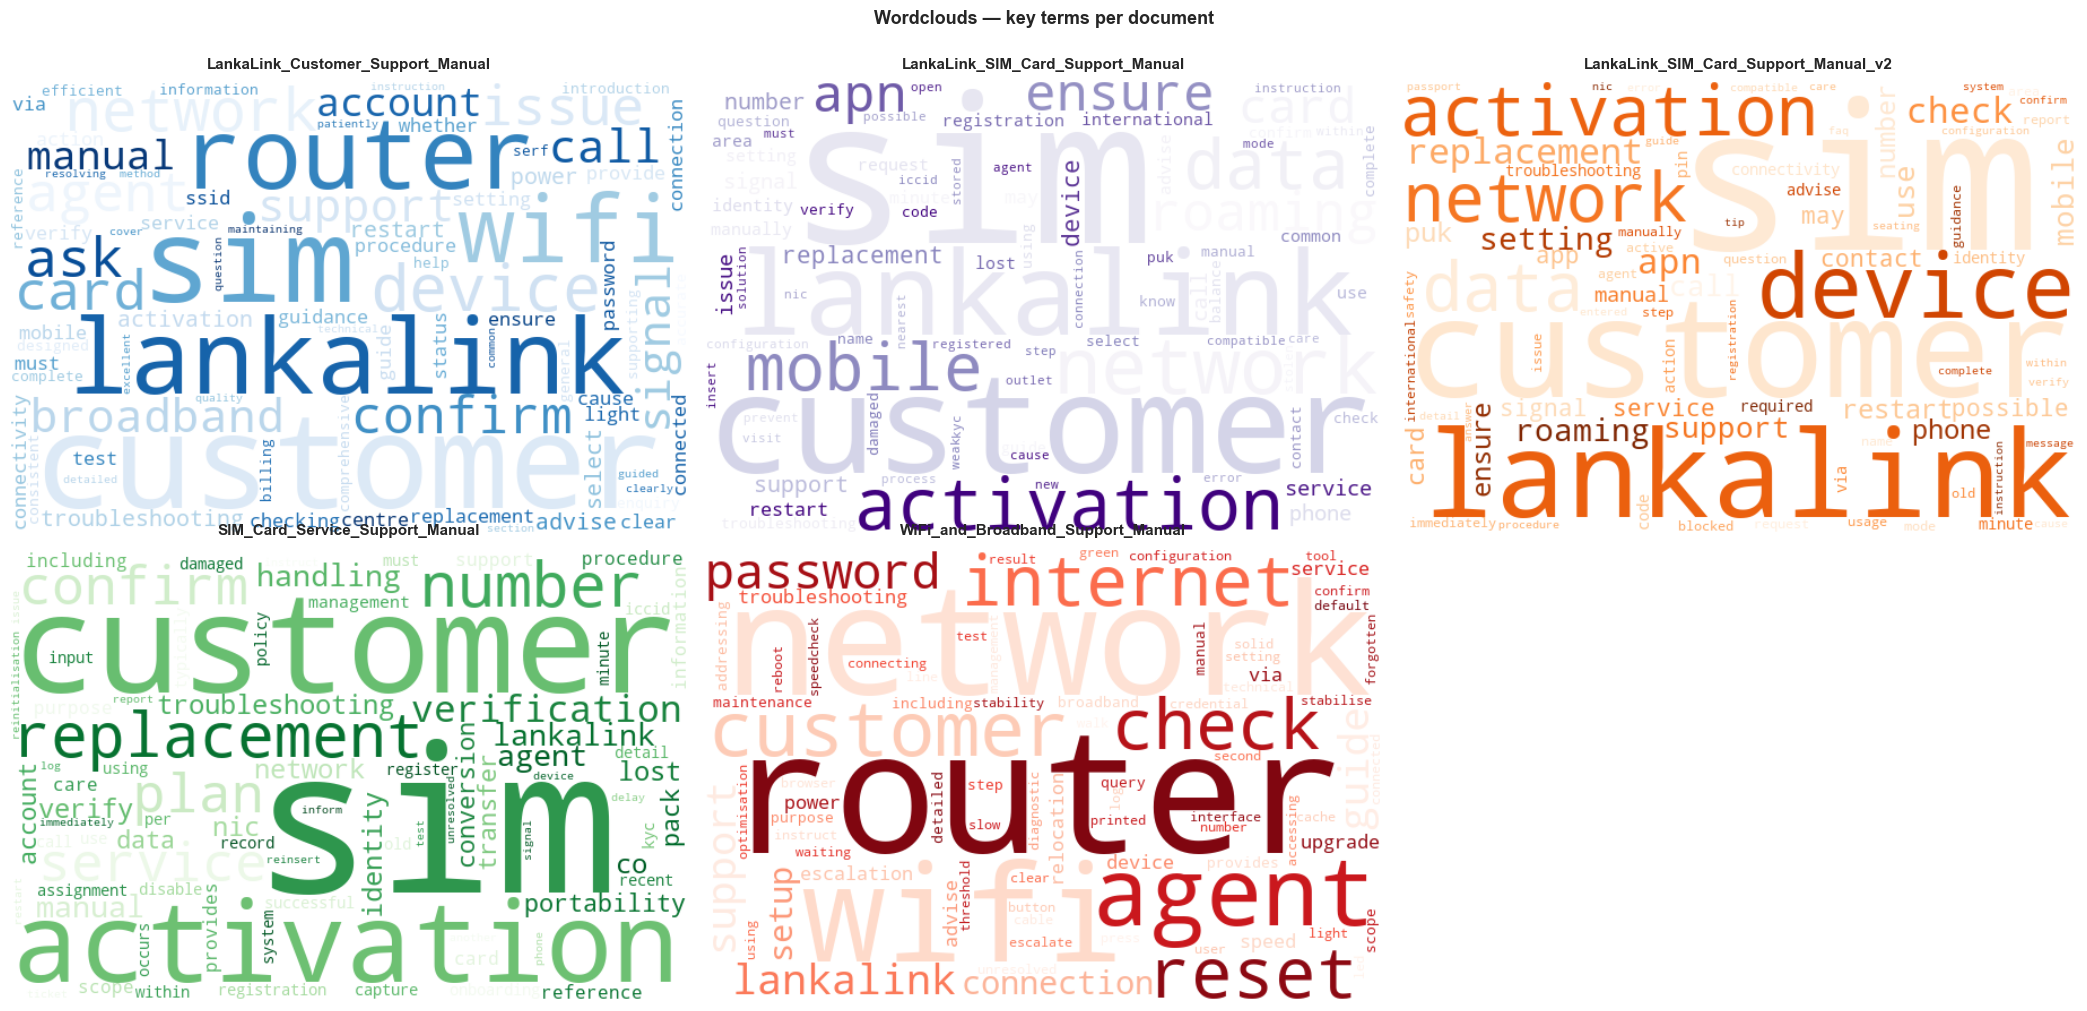

Figure saved: outputs/07_wordclouds.png


In [15]:
n_docs = len(documents)
ncols = min(n_docs, 3)
nrows = (n_docs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))

if n_docs == 1:
    axes_flat = [axes]
elif nrows == 1:
    axes_flat = list(axes)
else:
    axes_flat = axes.flatten().tolist()

wc_colors = ['Blues', 'Purples', 'Oranges', 'Greens', 'Reds', 'RdPu']

for i, (doc, ax) in enumerate(zip(documents, axes_flat)):
    tokens_joined = " ".join(doc["tokens"])  # already lemmatised & stopword-removed

    if not tokens_joined.strip():
        ax.text(0.5, 0.5, "No content",
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(doc["filename"].replace(".pdf", ""), fontweight='bold')
        ax.axis('off')
        continue

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=wc_colors[i % len(wc_colors)],
        max_words=80,
        prefer_horizontal=0.8,
        collocations=False,
    ).generate(tokens_joined)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(doc["filename"].replace(".pdf", ""), fontweight='bold', fontsize=11, pad=10)

for ax in axes_flat[n_docs:]:
    ax.set_visible(False)

plt.suptitle("Wordclouds — key terms per document", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/07_wordclouds.png")

## 8. Sentence Length & Readability Analysis

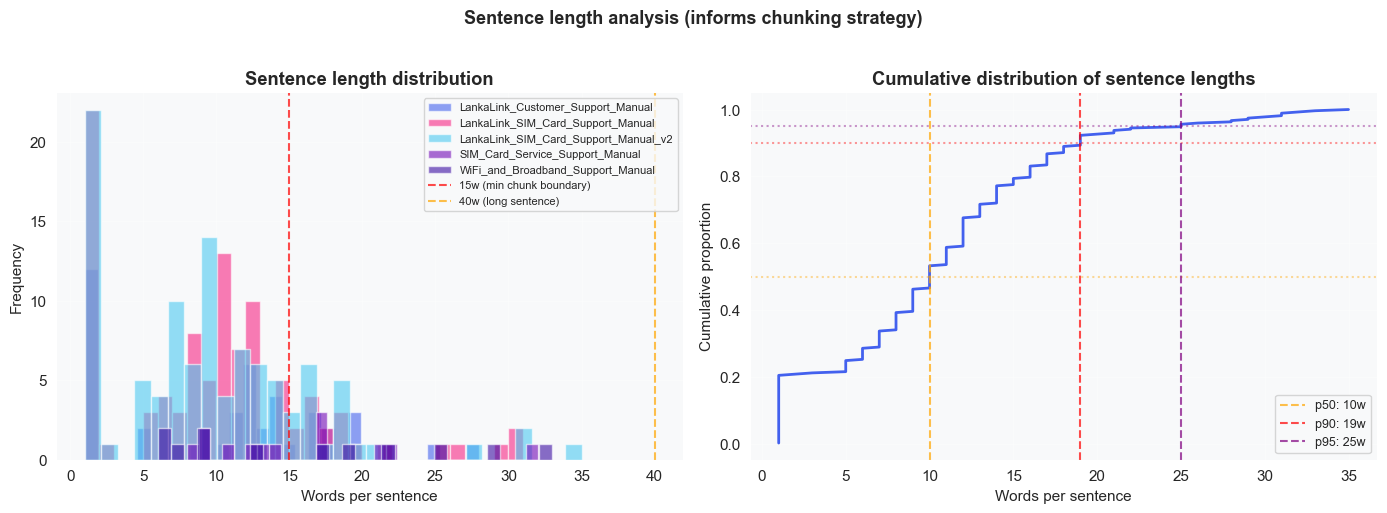

Sentence length percentiles:
p50 (median) : 10 words
p90          : 19 words
p95          : 25 words

RAG chunking implication: chunks of 256–512 tokens will typically contain 25 – 51 sentences, which is semantically coherent.
Figure saved: outputs/08_sentence_lengths.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, doc in enumerate(documents):
    sent_lengths = [len(s.split()) for s in doc["sentences"]]
    ax.hist(sent_lengths, bins=30, alpha=0.6,
            label=doc["filename"].replace(".pdf", ""),
            color=PALETTE[i % len(PALETTE)], edgecolor='white')

ax.axvline(15, color='red', linestyle='--', alpha=0.7, label='15w (min chunk boundary)')
ax.axvline(40, color='orange', linestyle='--', alpha=0.7, label='40w (long sentence)')
ax.set_xlabel("Words per sentence")
ax.set_ylabel("Frequency")
ax.set_title("Sentence length distribution", fontweight='bold')
ax.legend(fontsize=8)

ax = axes[1]
all_sent_lengths = []
for doc in documents:
    all_sent_lengths.extend([len(s.split()) for s in doc["sentences"]])

sorted_lens = np.sort(all_sent_lengths)
cdf = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens)
ax.plot(sorted_lens, cdf, color=PALETTE[0], linewidth=2)

for pct, color in [(50, 'orange'), (90, 'red'), (95, 'purple')]:
    val = np.percentile(all_sent_lengths, pct)
    ax.axvline(val, color=color, linestyle='--', alpha=0.7,
               label=f'p{pct}: {val:.0f}w')
    ax.axhline(pct / 100, color=color, linestyle=':', alpha=0.4)

ax.set_xlabel("Words per sentence")
ax.set_ylabel("Cumulative proportion")
ax.set_title("Cumulative distribution of sentence lengths", fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle("Sentence length analysis (informs chunking strategy)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_sentence_lengths.png", dpi=150, bbox_inches='tight')
plt.show()

p50 = np.percentile(all_sent_lengths, 50)
p90 = np.percentile(all_sent_lengths, 90)
p95 = np.percentile(all_sent_lengths, 95)
print(f"Sentence length percentiles:")
print(f"p50 (median) : {p50:.0f} words")
print(f"p90          : {p90:.0f} words")
print(f"p95          : {p95:.0f} words")
print()
print(
    f"RAG chunking implication: chunks of 256–512 tokens will typically contain {256 // max(p50, 1):.0f} – {512 // max(p50, 1):.0f} sentences, which is semantically coherent.")
print("Figure saved: outputs/08_sentence_lengths.png")

## 9. Domain-Specific Term Analysis

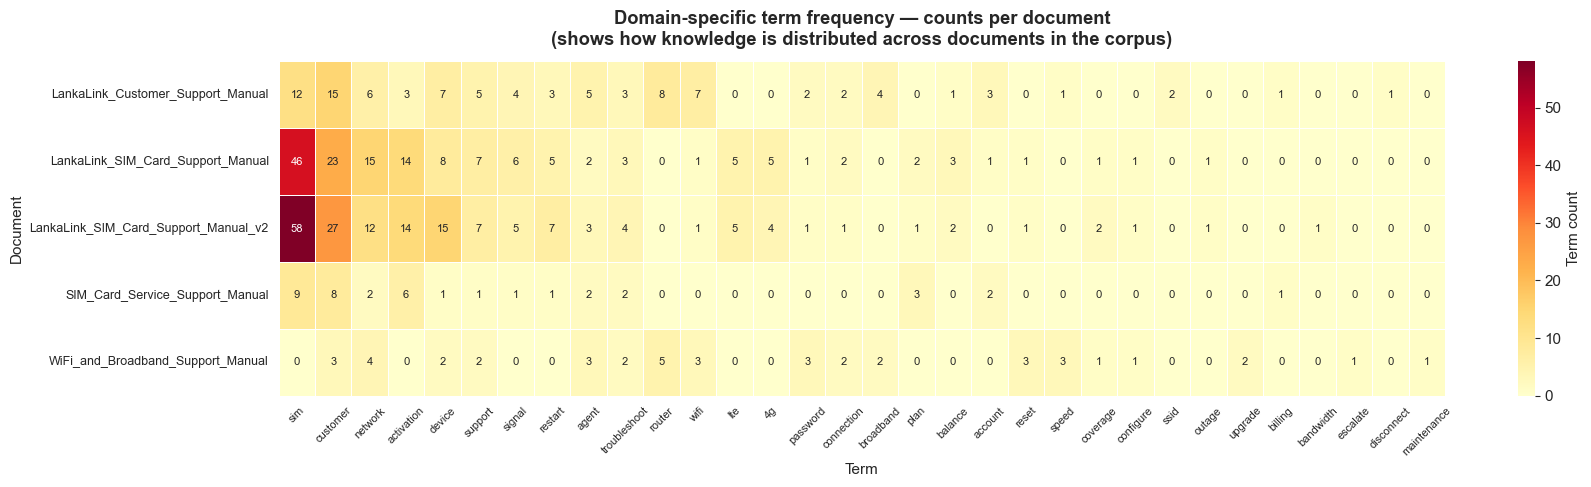

Figure saved: outputs/09_domain_terms.png


In [17]:
DOMAIN_TERMS = [
    "sim", "network", "signal", "router", "broadband", "wifi", "ssid",
    "bandwidth", "coverage", "4g", "5g", "lte", "fibre", "activation",
    "customer", "account", "billing", "invoice", "payment", "plan", "upgrade",
    "escalate", "agent", "support", "complaint", "refund", "balance",
    "troubleshoot", "restart", "reset", "configure", "password", "device",
    "connection", "disconnect", "speed", "latency", "outage", "maintenance",
]

domain_freq = {}
for doc in documents:
    text_lower = doc["full_text"].lower()
    doc_name = doc["filename"].replace(".pdf", "")
    domain_freq[doc_name] = {
        term: text_lower.count(term) for term in DOMAIN_TERMS
    }

domain_df = pd.DataFrame(domain_freq).T
domain_df = domain_df[domain_df.sum().sort_values(ascending=False).index]

domain_df = domain_df.loc[:, (domain_df > 0).any()]

fig, ax = plt.subplots(figsize=(max(14, len(domain_df.columns) * 0.55), max(5, len(domain_df) * 0.9)))
sns.heatmap(
    domain_df,
    ax=ax,
    cmap="YlOrRd",
    annot=True, fmt='d',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Term count'},
    annot_kws={'size': 8},
)
ax.set_title("Domain-specific term frequency — counts per document\n"
             "(shows how knowledge is distributed across documents in the corpus)",
             fontweight='bold', pad=12)
ax.set_xlabel("Term")
ax.set_ylabel("Document")
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_domain_terms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/09_domain_terms.png")

## 10. EDA Summary & Key Findings

In [18]:
total_words = sum(d['total_words'] for d in documents)
total_pages = sum(d['total_pages'] for d in documents)
total_sents = sum(d['sentence_count'] for d in documents)
corpus_vocab = len(set(all_tokens_combined))
avg_wpp = total_words / max(total_pages, 1)

print(" EDA SUMMARY — KEY FINDINGS")
print(f"""
Documents              : {len(documents)}
Total pages            : {total_pages}
Total words            : {total_words:,}
Total sentences        : {total_sents:,}
Corpus vocabulary      : {corpus_vocab:,} unique tokens
Avg words/page         : {avg_wpp:.0f}
Median sentence length : {np.median(all_sent_lengths):.0f}
Vocabulary coverage    : {corpus_vocab:,} unique domain-specific tokens.
Corpus size            : {total_words:,} words total
""")

 EDA SUMMARY — KEY FINDINGS

Documents              : 5
Total pages            : 23
Total words            : 2,820
Total sentences        : 272
Corpus vocabulary      : 536 unique tokens
Avg words/page         : 123
Median sentence length : 10
Vocabulary coverage    : 536 unique domain-specific tokens.
Corpus size            : 2,820 words total


## 11. Save Corpus to JSON

In [19]:
corpus_export = []
for doc in documents:
    corpus_export.append({
        "filename": doc["filename"],
        "filepath": doc["filepath"],
        "doc_id": doc["doc_id"],
        "total_pages": doc["total_pages"],
        "empty_pages": doc["empty_pages"],
        "total_words": doc["total_words"],
        "total_chars": doc["total_chars"],
        "sentence_count": doc["sentence_count"],
        "vocab_size": doc["vocab_size"],
        "avg_sent_len": doc["avg_sent_len"],
        "extraction_status": doc["extraction_status"],
        "full_text": doc["full_text"],
        "pages": [
            {
                "page_number": p["page_number"],
                "word_count": p["word_count"],
                "char_count": p["char_count"],
                "is_empty": p["is_empty"],
                "raw_text": p["raw_text"],
            }
            for p in doc["pages"]
        ]
    })

corpus_path = OUTPUT_DIR / "corpus.json"
with open(corpus_path, "w", encoding="utf-8") as f:
    json.dump(corpus_export, f, indent=2, ensure_ascii=False)

file_size_kb = corpus_path.stat().st_size / 1024
print(f"Corpus saved {corpus_path}")
print(f"Documents: {len(corpus_export)}")
print(f"Total words in corpus: {sum(d['total_words'] for d in corpus_export):,}")

Corpus saved outputs\corpus.json
Documents: 5
Total words in corpus: 2,820
